# Imports

In [11]:
import torch
from torch import nn
from torch.nn import CrossEntropyLoss
from torch.utils.data import DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
from LabelMapper import LabelMapper
from RuralDataset import RuralDataset
from SegmentationModel import SegmentationModel
from Trainer import Trainer
from Evaluator import Evaluator
from ImageProcessor import ImageProcessor
from DiceLoss import DiceLoss
from ResNet import *
torch.cuda.empty_cache()

# Configuration parameters

In [12]:
DATA_ROOT = 'train'
BATCH_SIZE = 4
LEARNING_RATE = 0.001
NUM_EPOCHS = 10
NUM_CLASSES = 9
MODEL_SAVE_PATH = 'saved_model.pth'

# Device configuration

In [13]:
if torch.cuda.is_available():
    device = torch.device('cuda')  # Configura per utilizzare la GPU
    print(f"Utilizzo GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device('cpu')  # Fallback alla CPU
    print("CUDA non disponibile, utilizzo CPU")

Utilizzo GPU: NVIDIA GeForce RTX 5070 Ti


# Transforms initialization

In [14]:
train_transform = transforms.Compose([
    #transforms.Resize((272,512)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
val_transform = transforms.Compose([
    #transforms.Resize((272,512)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Dataset loading and splitting into training and validation sets

In [15]:
# Crea dataset separati con le rispettive trasformazioni
from torch.utils.data import random_split

# Applica la trasformazione di training e validazione ai rispettivi dataset
full_dataset = RuralDataset(root_dir=DATA_ROOT)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

# Suddividi il dataset in train e val
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Applica le trasformazioni ai sotto-dataset
# NOTA: random_split restituisce Subset, quindi bisogna settare la transform manualmente
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_transform

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, num_workers=16, shuffle=True,
    pin_memory=True)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, num_workers=16, shuffle=False,
    pin_memory=True)

print(f"Training on {len(train_dataset)} samples, validating on {len(val_dataset)} samples.")

Training on 744 samples, validating on 187 samples.


# Model initialization

In [16]:
model = ResNet152(num_classes=NUM_CLASSES)
model.to(device)
print("Model architecture:")
print(model)

Model architecture:
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (batch_norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (max_pool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
      (batch_norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (batch_norm2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1))
      (batch_norm3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (i_downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1))
        (1): BatchNorm

# Loss Function and optimizer definition

In [17]:
# weights = Trainer.compute_class_weights(train_loader,NUM_CLASSES).to(device)
# print(weights)

# 0: 11609844, 1: 41857083, 2: 61816044, 3: 64655385, 4: 57234268, 5: 149050513, 6: 24045406, 7: 730491, 8: 3450630
weights =[ 3.8332,  1.0790,  0.7218,  0.7481,  0.8233,  0.3108,  1.7673, 70.4379, 12.8048]
# weight=torch.tensor(weights, dtype=torch.float32).to(device)
# criterion = CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32).to(device))
criterion = DiceLoss(num_classes=NUM_CLASSES, ignore_index=0)
# criterion = CrossEntropyLoss()

In [18]:
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
#optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9, weight_decay=0.0001)



# Trainer initialization and training

In [ ]:
trainer = Trainer(model, train_loader, val_loader, criterion, optimizer, device)
print("\nStarting training...")
trainer.run(num_epochs=NUM_EPOCHS, model_save_path=MODEL_SAVE_PATH)
print("Training finished.")


Starting training...

Epoch 1/10
Batch 1/186, Loss: 0.9018
Batch 2/186, Loss: 0.8656
Batch 3/186, Loss: 0.8311
Batch 4/186, Loss: 0.8249
Batch 5/186, Loss: 0.8875
Batch 6/186, Loss: 0.8465
Batch 7/186, Loss: 0.9191
Batch 8/186, Loss: 0.8696
Batch 9/186, Loss: 0.8453
Batch 10/186, Loss: 0.8280
Batch 11/186, Loss: 0.7852
Batch 12/186, Loss: 0.8057
Batch 13/186, Loss: 0.7704
Batch 14/186, Loss: 0.7799
Batch 15/186, Loss: 0.6917
Batch 16/186, Loss: 0.7508
Batch 17/186, Loss: 0.8310
Batch 18/186, Loss: 0.7833
Batch 19/186, Loss: 0.8004
Batch 20/186, Loss: 0.8050
Batch 21/186, Loss: 0.8203
Batch 22/186, Loss: 0.8140
Batch 23/186, Loss: 0.8147
Batch 24/186, Loss: 0.8437
Batch 25/186, Loss: 0.7703
Batch 26/186, Loss: 0.7962
Batch 27/186, Loss: 0.6619
Batch 28/186, Loss: 0.6378
Batch 29/186, Loss: 0.6417
Batch 30/186, Loss: 0.6288
Batch 31/186, Loss: 0.3548
Batch 32/186, Loss: 0.6164
Batch 33/186, Loss: 0.4702
Batch 34/186, Loss: 0.5900
Batch 35/186, Loss: 0.7107
Batch 36/186, Loss: 0.6972
Bat

# Model evaluation

In [10]:
model.load_state_dict(torch.load(MODEL_SAVE_PATH))

evaluator = Evaluator(model, val_loader, device)
metrics = evaluator.evaluate_classification_metrics()

# Example Predict

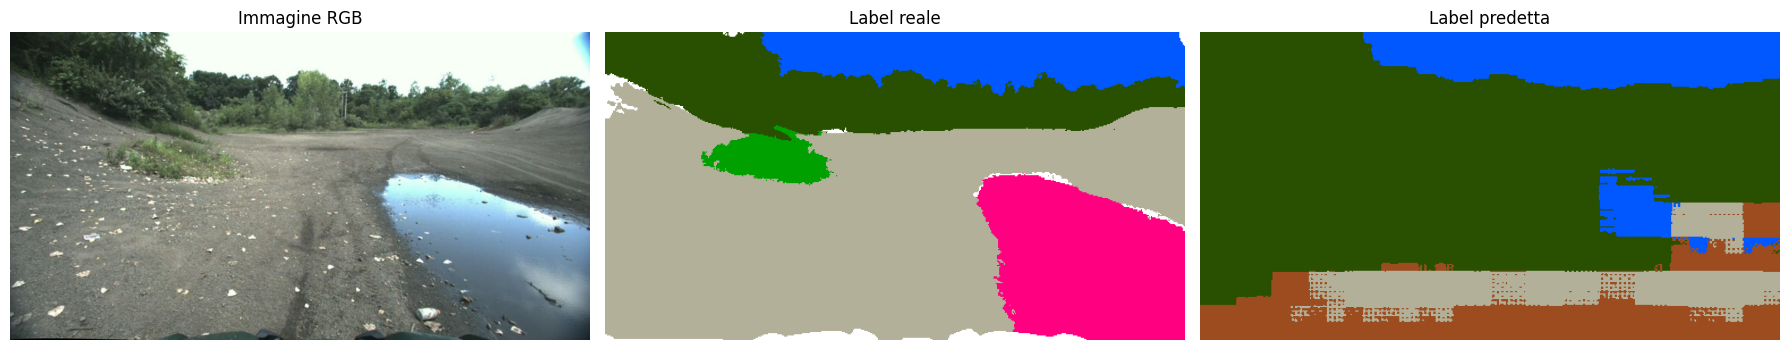

Pixel classificati correttamente: 47940 / 139264 (34.42%)
IoU medio sull'immagine: 0.1926
IoU per classe: [0.76346793 0.         0.10722366        nan 0.28472692 0.
 0.                nan]


In [16]:
evaluator.predict_from_folder(folder_number = 511)

In [12]:
print(metrics.get('accuracy', 'N/A'))
print(metrics.get('f1_score', 'N/A'))
print(metrics.get('precision', 'N/A'))
print(metrics.get('recall', 'N/A'))

0.5972214585094566
N/A
0.3440237585940638
0.36290110029417344
